# Paper Figures v4

This notebook regenerates the final paper figures **only from locked `revised_outputs_v4` CSV outputs**. It does **not** retrain LSTM or XGBoost models.

It creates:

- `Fig1_information_scope.pdf` and `.png`
- `Fig2_provider_shift.pdf` and `.png`

The PDF files are vector graphics for Overleaf; PNG files are 600 dpi backups.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/Crypto_Research')
OUTPUT_ROOT = PROJECT_DIR / 'revised_outputs_v4'
FIGURE_DIR = OUTPUT_ROOT / 'paper_figures'

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("FIGURE_DIR:", FIGURE_DIR)
print("OUTPUT_ROOT exists:", OUTPUT_ROOT.exists())

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/Crypto_Research
OUTPUT_ROOT: /content/drive/MyDrive/Crypto_Research/revised_outputs_v4
FIGURE_DIR: /content/drive/MyDrive/Crypto_Research/revised_outputs_v4/paper_figures
OUTPUT_ROOT exists: True


## IEEE figure style

IEEE's conference template recommends approximately 8 pt Times New Roman for figure labels. This cell selects the first available Times-like serif font and uses 8 pt labels. No manual change to IEEE paper margins or column widths is involved.

In [ ]:
# Choose an available Times-like serif font.
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
font_candidates = [
    'Times New Roman',
    'Times',
    'Nimbus Roman',
    'TeX Gyre Termes',
    'Liberation Serif',
]
chosen_font = next((f for f in font_candidates if f in available_fonts), 'serif')

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': [chosen_font],
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.8,
})

print('Figure font:', chosen_font)

Figure font: Liberation Serif


## Figure 1: Information scope

Source: `phase3/ensemble_metrics.csv`

The figure compares held-out LSTM MAE for **general-news FinBERT** and **crypto-specific FinBERT** for BTC and ETH. The bars start at zero so the small differences are not visually exaggerated; exact MAEs are printed above the bars.

In [ ]:
phase3_path = OUTPUT_ROOT / 'phase3' / 'ensemble_metrics.csv'
phase3 = pd.read_csv(phase3_path)

methods = {
    'General-news FinBERT': 'phase2_general_lstm',
    'Crypto-specific FinBERT': 'phase3_crypto_lstm',
}
assets = ['BTC', 'ETH']

fig1_values = {}
for label, method in methods.items():
    vals = []
    for asset in assets:
        row = phase3[(phase3['asset'] == asset) & (phase3['method'] == method)]
        if len(row) != 1:
            raise ValueError(f'Expected exactly one row for {asset}, {method}; found {len(row)}')
        vals.append(float(row.iloc[0]['mae']))
    fig1_values[label] = vals

fig1_df = pd.DataFrame(fig1_values, index=assets)
fig1_df

,General-news FinBERT,Crypto-specific FinBERT
BTC,0.016615,0.017040
ETH,0.024451,0.023513


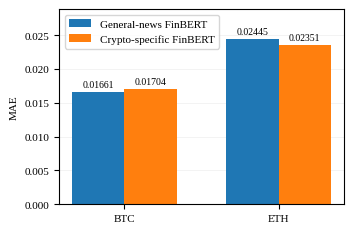

Saved: /content/drive/MyDrive/Crypto_Research/revised_outputs_v4/paper_figures/Fig1_information_scope.pdf


In [ ]:
x = np.arange(len(assets))
width = 0.34

fig, ax = plt.subplots(figsize=(3.45, 2.25))

for i, (label, values) in enumerate(fig1_values.items()):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, values, width=width, label=label)
    for bar, value in zip(bars, values):
        ax.annotate(
            f'{value:.5f}',
            xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
            xytext=(0, 2),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=7,
        )

ax.set_xticks(x, assets)
ax.set_ylabel('MAE')
ax.set_ylim(0, max(max(v) for v in fig1_values.values()) * 1.18)
ax.legend(frameon=True, loc='upper left')
ax.grid(axis='y', alpha=0.20, linewidth=0.5)
ax.set_axisbelow(True)

fig.tight_layout(pad=0.5)
fig.savefig(FIGURE_DIR / 'Fig1_information_scope.pdf', bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'Fig1_information_scope.png', dpi=600, bbox_inches='tight')
plt.show()

print('Saved:', FIGURE_DIR / 'Fig1_information_scope.pdf')

## Figure 2: Provider coverage shift diagnostic

Source: `phase5_reliability_fusion/provider_shift_weight_diagnostics.csv`

The paper figure uses only the `original` and `normalized` rules. It compares the **mean general-news reliability weight** before and after October 2025. The count-weight correlations are reported separately in the paper text and are not implied by the bars themselves.

In [ ]:
diag_path = OUTPUT_ROOT / 'phase5_reliability_fusion' / 'provider_shift_weight_diagnostics.csv'
diag = pd.read_csv(diag_path)

plot_diag = diag[diag['mode'].isin(['original', 'normalized'])].copy()

order = [
    ('BTC', 'original'),
    ('BTC', 'normalized'),
    ('ETH', 'original'),
    ('ETH', 'normalized'),
]
periods = ['pre_2025_10', 'post_2025_10']
period_labels = ['Pre Oct. 2025', 'Post Oct. 2025']

fig2_values = {period: [] for period in periods}
for asset, mode in order:
    for period in periods:
        row = plot_diag[(plot_diag['asset'] == asset) &
                        (plot_diag['mode'] == mode) &
                        (plot_diag['period'] == period)]
        if len(row) != 1:
            raise ValueError(f'Expected one row for {asset}, {mode}, {period}; found {len(row)}')
        fig2_values[period].append(float(row.iloc[0]['mean_general_weight']))

labels = ['BTC\nOriginal', 'BTC\nNormalized', 'ETH\nOriginal', 'ETH\nNormalized']
fig2_df = pd.DataFrame({
    period_labels[0]: fig2_values[periods[0]],
    period_labels[1]: fig2_values[periods[1]],
}, index=labels)
fig2_df

,Pre Oct. 2025,Post Oct. 2025
BTC\nOriginal,0.528354,0.917028
BTC\nNormalized,0.506809,0.423731
ETH\nOriginal,0.525469,0.910178
ETH\nNormalized,0.501652,0.389691


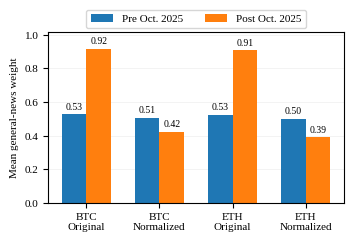

Saved: /content/drive/MyDrive/Crypto_Research/revised_outputs_v4/paper_figures/Fig2_provider_shift.pdf


In [ ]:
x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(3.45, 2.35))

for i, period in enumerate(periods):
    values = fig2_values[period]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, values, width=width, label=period_labels[i])
    for bar, value in zip(bars, values):
        ax.annotate(
            f'{value:.2f}',
            xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
            xytext=(0, 2),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=7,
        )

ax.set_xticks(x, labels, rotation=0)
ax.set_ylabel('Mean general-news weight')
ax.set_ylim(0, 1.02)
ax.legend(frameon=True, loc='upper center', bbox_to_anchor=(0.5, 1.16), ncol=2)
ax.grid(axis='y', alpha=0.20, linewidth=0.5)
ax.set_axisbelow(True)

fig.tight_layout(pad=0.5)
fig.savefig(FIGURE_DIR / 'Fig2_provider_shift.pdf', bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'Fig2_provider_shift.png', dpi=600, bbox_inches='tight')
plt.show()

print('Saved:', FIGURE_DIR / 'Fig2_provider_shift.pdf')

## Sanity checks for manuscript values

This cell prints the exact values used in the figures and the post-shift count-weight correlations cited in the manuscript. It is a plotting/data check only.

In [ ]:
print('FIGURE 1 HELD-OUT MAE')
print(fig1_df.to_string())

print('\nFIGURE 2 MEAN GENERAL-NEWS WEIGHTS')
print(fig2_df.to_string())

post_corr = diag[(diag['mode'].isin(['original', 'normalized'])) &
                 (diag['period'] == 'post_2025_10')][
    ['asset', 'mode', 'corr_log_general_count_general_weight']
].copy()
print('\nPOST-SHIFT COUNT-WEIGHT CORRELATIONS')
print(post_corr.to_string(index=False))

# Expected final-paper values (approximately):
# BTC Phase 2 general-news LSTM MAE: 0.016615
# BTC Phase 3 crypto-specific LSTM MAE: 0.017040
# ETH Phase 2 general-news LSTM MAE: 0.024451
# ETH Phase 3 crypto-specific LSTM MAE: 0.023513
# Post-shift original corr: ~0.79 BTC, ~0.81 ETH
# Post-shift normalized corr: ~0.01 BTC, ~0.04 ETH

FIGURE 1 HELD-OUT MAE
     General-news FinBERT  Crypto-specific FinBERT
BTC              0.016615                 0.017040
ETH              0.024451                 0.023513

FIGURE 2 MEAN GENERAL-NEWS WEIGHTS
                 Pre Oct. 2025  Post Oct. 2025
BTC\nOriginal         0.528354        0.917028
BTC\nNormalized       0.506809        0.423731
ETH\nOriginal         0.525469        0.910178
ETH\nNormalized       0.501652        0.389691

POST-SHIFT COUNT-WEIGHT CORRELATIONS
asset       mode  corr_log_general_count_general_weight
  BTC   original                               0.791033
  BTC normalized                               0.011282
  ETH   original                               0.805275
  ETH normalized                               0.037176


## Overleaf

Upload the two vector PDF files from `revised_outputs_v4/paper_figures/` and use them directly, for example:

```latex
\includegraphics[width=\columnwidth]{Fig1_information_scope.pdf}
```

```latex
\includegraphics[width=\columnwidth]{Fig2_provider_shift.pdf}
```

Do not rerun Phase 0–5 merely to regenerate these paper figures.